In [1]:
import pickle
#import pandas as pd
import networkx as nx
import pennylane as qml
from pennylane import numpy as np

/work/acslab/users/baobach/anaconda3/envs/lightninggpu/lib/python3.12/site-packages/pennylane/__init__.py:212: PennyLaneDeprecationWarning: PennyLane v0.44 has dropped maintainence support for NumPy < 2.0.0. You have version 1.26.4 installed. Future versions of PennyLane will not work with NumPy<2.0. Please consider upgrading NumPy using `python -m pip install numpy --upgrade`. 
  warnings.warn(


In [37]:
#Vlist = [np.diag(P[:, i]) - P[:, i].reshape(P.shape[0], 1) * P[:, i].reshape(1, P.shape[0]) for i in range(P.shape[1])]

In [2]:
#import numpy as np
from dataclasses import dataclass
from scipy.optimize import differential_evolution, minimize


@dataclass
class IsingInstance:
    h: np.ndarray               # diagonal terms h_i
    J: np.ndarray               # off-diagonal couplings J_ij, symmetric, zero diagonal
    neighbors: list            # neighbors[i] = set of vertices k with J[i,k] != 0
    edges: list                # list of (i,j) with i < j and J[i,j] != 0

    @staticmethod
    def from_matrix(M: np.ndarray, tol: float = 1e-12) -> "IsingInstance":
        """
        Build the Ising instance from a symmetric matrix M:
          M[i,i] = h_i
          M[i,j] = J_ij for i != j
        """
        M = np.asarray(M, dtype=float)

        if M.ndim != 2 or M.shape[0] != M.shape[1]:
            raise ValueError("Input matrix must be square.")
        if not np.allclose(M, M.T, atol=tol):
            raise ValueError("Input matrix must be symmetric.")

        n = M.shape[0]
        h = np.diag(M).copy()
        J = M.copy()
        np.fill_diagonal(J, 0.0)

        neighbors = []
        edges = []
        for i in range(n):
            nbrs = set(np.where(np.abs(J[i]) > tol)[0].tolist())
            neighbors.append(nbrs)

        for i in range(n):
            for j in range(i + 1, n):
                if abs(J[i, j]) > tol:
                    edges.append((i, j))

        return IsingInstance(h=h, J=J, neighbors=neighbors, edges=edges)


def _prod_cos(values, gamma: float) -> float:
    """
    Compute product of cos(2*gamma*x) over x in values.
    Empty product = 1.
    """
    vals = np.array(list(values), dtype=float)
    if vals.size == 0:
        return 1.0
    return float(np.prod(np.cos(2.0 * gamma * vals)))


def exp_Ci(beta: float, gamma: float, inst: IsingInstance, i: int) -> float:
    """
    Eq. (12), first line:
      <C_i> = h_i sin(2β) sin(2γ h_i) * Π_{(ik)∈E} cos(2γ J_ik)
    """
    hi = inst.h[i]
    prod_neighbors = _prod_cos((inst.J[i, k] for k in inst.neighbors[i]), gamma)

    return float(
        hi
        * np.sin(2.0 * beta)
        * np.sin(2.0 * gamma * hi)
        * prod_neighbors
    )


def exp_Cij(beta: float, gamma: float, inst: IsingInstance, i: int, j: int) -> float:
    """
    Eq. (12), general sparse-graph formula for <C_ij>.
    Assumes i != j and J_ij != 0.
    """
    Jij = inst.J[i, j]
    if Jij == 0.0:
        return 0.0

    hi = inst.h[i]
    hj = inst.h[j]

    Ni = inst.neighbors[i] - {j}
    Nj = inst.neighbors[j] - {i}

    common = Ni & Nj              # k connected to both i and j
    only_i = Ni - Nj              # k connected to i but not j
    only_j = Nj - Ni              # k connected to j but not i

    # First bracket:
    # cos(2γ h_i) Π_{(ik)∈E, k!=j} cos(2γ J_ik)
    # + cos(2γ h_j) Π_{(jk)∈E, k!=i} cos(2γ J_jk)
    prod_Ni = _prod_cos((inst.J[i, k] for k in Ni), gamma)
    prod_Nj = _prod_cos((inst.J[j, k] for k in Nj), gamma)

    first_term = (
        0.5 * Jij * np.sin(4.0 * beta) * np.sin(2.0 * gamma * Jij)
        * (
            np.cos(2.0 * gamma * hi) * prod_Ni
            + np.cos(2.0 * gamma * hj) * prod_Nj
        )
    )

    # Second bracket:
    # Π_{i-only} cos(2γ J_ik) * Π_{j-only} cos(2γ J_jk)
    # * [ cos(2γ(h_i+h_j)) Π_common cos(2γ(J_ik+J_jk))
    #   - cos(2γ(h_i-h_j)) Π_common cos(2γ(J_ik-J_jk)) ]
    prod_only_i = _prod_cos((inst.J[i, k] for k in only_i), gamma)
    prod_only_j = _prod_cos((inst.J[j, k] for k in only_j), gamma)

    prod_common_plus = _prod_cos((inst.J[i, k] + inst.J[j, k] for k in common), gamma)
    prod_common_minus = _prod_cos((inst.J[i, k] - inst.J[j, k] for k in common), gamma)

    second_bracket = (
        np.cos(2.0 * gamma * (hi + hj)) * prod_common_plus
        - np.cos(2.0 * gamma * (hi - hj)) * prod_common_minus
    )

    second_term = (
        0.5 * Jij * (np.sin(2.0 * beta) ** 2)
        * prod_only_i
        * prod_only_j
        * second_bracket
    )

    return float(first_term - second_term)


def qaoa_p1_expectation(beta: float, gamma: float, inst: IsingInstance) -> float:
    """
    F(β,γ) = sum_i <C_i> + sum_(i,j) <C_ij>
    """
    total = 0.0

    for i in range(len(inst.h)):
        total += exp_Ci(beta, gamma, inst, i)

    for i, j in inst.edges:
        total += exp_Cij(beta, gamma, inst, i, j)

    return float(total)


def qaoa_p1_expectation_from_matrix(beta: float, gamma: float, M: np.ndarray) -> float:
    inst = IsingInstance.from_matrix(M)
    return qaoa_p1_expectation(beta, gamma, inst)


def optimize_qaoa_p1(
    M: np.ndarray,
    beta_bounds=(-np.pi / 2, np.pi / 2),
    gamma_bounds=(-np.pi, np.pi),
    sense: str = "min",
    seed: int | None = None,
):
    """
    Optimize the p=1 QAOA expected energy F(β,γ) for H_C.

    Parameters
    ----------
    M : symmetric matrix
        diag(M) = h_i, offdiag(M) = J_ij
    beta_bounds, gamma_bounds : tuples
        Search box for (beta, gamma)
    sense : "min" or "max"
        Usually use "min" for Ising minimization.
    seed : int or None
        Random seed for differential evolution.

    Returns
    -------
    dict with best beta, gamma, objective value, and raw scipy results
    """
    inst = IsingInstance.from_matrix(M)

    if sense not in {"min", "max"}:
        raise ValueError("sense must be 'min' or 'max'")

    sign = 1.0 if sense == "min" else -1.0

    def objective(x):
        beta, gamma = x
        return sign * qaoa_p1_expectation(beta, gamma, inst)

    bounds = [beta_bounds, gamma_bounds]

    # Global search first
    de_res = differential_evolution(
        objective,
        bounds=bounds,
        seed=seed,
        polish=False,
        updating="deferred",
    )

    # Local polish
    local_res = minimize(
        objective,
        x0=de_res.x,
        method="L-BFGS-B",
        bounds=bounds,
    )

    if local_res.fun < de_res.fun:
        x_best = local_res.x
        raw_best = local_res
    else:
        x_best = de_res.x
        raw_best = de_res

    beta_star, gamma_star = map(float, x_best)
    F_star = qaoa_p1_expectation(beta_star, gamma_star, inst)

    return {
        "beta": beta_star,
        "gamma": gamma_star,
        "F": float(F_star),
        "sense": sense,
        "success": bool(getattr(raw_best, "success", True)),
        "global_result": de_res,
        "local_result": local_res,
    }


def landscape_grid(
    M: np.ndarray,
    betas: np.ndarray,
    gammas: np.ndarray,
) -> np.ndarray:
    """
    Compute F(beta, gamma) on a grid.
    Returns an array shape (len(gammas), len(betas)).
    """
    inst = IsingInstance.from_matrix(M)
    Z = np.empty((len(gammas), len(betas)), dtype=float)

    for a, gamma in enumerate(gammas):
        for b, beta in enumerate(betas):
            Z[a, b] = qaoa_p1_expectation(beta, gamma, inst)

    return Z

In [3]:
P = np.load('/work/acslab/users/baobach/quantum_hypergraph/QuantumHypergraphPartitioning/data/noisy_karloff/6_3_1_0.npy')

In [4]:
def make_M_V(P, w):
    M = P @ np.diag(w) @ P.T
    return M, np.diag(P @ w) - M

In [5]:
Q_1 = make_M_V(P, np.ones(P.shape[1]))[0]
Q_2 = make_M_V(np.ones((P.shape[0], 1)) / P.shape[0], np.ones(1))[1]
Q_1_max_eigen = np.max(np.linalg.eigh(Q_1)[0])
Q_1_normalized = Q_1/Q_1_max_eigen
Q_2_max_eigen = np.max(np.linalg.eigh(Q_2)[0])
Q_2_normalized = Q_2/Q_2_max_eigen

In [6]:
edges = [np.where(P[:, i] > 0) for i in range(P.shape[1])]

In [7]:
inst = IsingInstance.from_matrix(Q_1)

In [8]:
len(inst.edges)

157

In [9]:
inst.h

tensor([1.1037415 , 1.27735261, 1.23763039, 0.72222222, 1.26583333,
        1.91666667, 1.36472222, 1.63722222, 2.00151927, 1.49833333,
        2.12333333, 1.43901927, 1.3087415 , 1.42722222, 2.35207483,
        2.18583333, 1.30222222, 1.63194444, 2.15305556, 1.56083333], requires_grad=True)

In [13]:
n_wires = 20
scaling_constant = 5e-2
num_layers = 1
beta_params = scaling_constant * np.random.random([1, num_layers], requires_grad=True) 
gamma_params = scaling_constant * np.random.random([1, num_layers], requires_grad=True) 

# Training ...
def U_B(beta):
    for wire in range(n_wires):
        qml.RX(inst.h[wire] * 2 * beta[0], wires=wire)
def U_C(gamma):
    for u, v in inst.edges:
        qml.CNOT(wires=(u, v))
        qml.RZ(-inst.J[u][v] * gamma[0], wires=v)
        qml.CNOT(wires=(u, v))

dev = qml.device('default.qubit', wires=n_wires)
@qml.qnode(dev)
def circuit(gammas, betas):
    for wire in range(n_wires):
        qml.Hadamard(wires=wire)
    for k in range(num_layers):
        U_C(gammas[:, k])
        U_B(betas[:, k])
    return [qml.expval(qml.PauliZ(u)) for u in range(n_wires)] + [qml.expval(qml.PauliZ(u) @ qml.PauliZ(v)) for u, v in inst.edges]

def objective(gammas, betas):
    expectation_values = circuit(gammas, betas)
    expectation_values = np.array(expectation_values)
    expectation_value = 0.0
    for wire in range(n_wires): 
        expectation_value += inst.h[wire] * expectation_values[wire]
    for edge_idx in range(len(inst.edges)):
        u, v = inst.edges[edge_idx]
        expectation_value += inst.J[u][v] * expectation_values[n_wires + edge_idx]
    return -expectation_value

In [ ]:
opt = qml.AdamOptimizer(stepsize=0.05)
regularized_objective_list = [objective(gamma_params, beta_params)]
params_list = [(gamma_params, beta_params)]
for i in range(500):
    (gamma_params, beta_params), current_obj = opt.step_and_cost(objective, gamma_params, beta_params)
    if (i + 1) % 5 == 0:
        print("Current obj: ", current_obj)
        if np.abs(current_obj - regularized_objective_list[-1]) <= 1e-4:
            regularized_objective_list.append(current_obj)
            params_list.append((gamma_params, beta_params))
            break
    regularized_objective_list.append(current_obj)
    params_list.append((gamma_params, beta_params))

Current obj:  -0.32025973311765943
Current obj:  -3.4230696272098298
Current obj:  -6.258170077247275
Current obj:  -8.485857230796805
Current obj:  -9.406881338686334
Current obj:  -9.390973800831189
Current obj:  -9.220819674957731
Current obj:  -9.25143824190242
Current obj:  -9.410585838754779


In [139]:
import numpy as np
F_res = []
F_params = []
for alpha in np.linspace(0, 1, 10):
#alpha = 0.5
    M = (1-alpha)*Q_1_normalized + alpha*Q_2_normalized
    #M = Q_1
    # Optimize p=1 QAOA expectation
    res = optimize_qaoa_p1(
        M,
        beta_bounds=(-np.pi, np.pi),
        gamma_bounds=(-np.pi, np.pi),
        sense="max",
        seed=123,
    )

    print("beta* =", res["beta"])
    print("gamma* =", res["gamma"])
    print("F* =", res["F"])
    F_params.append((res["gamma"], res["beta"]))
    F_res.append(res["F"])

beta* = -2.391644749103177
gamma* = 0.34197476971196666
F* = 38.92598142605274
beta* = -0.7503660321580723
gamma* = -0.3842800654503722
F* = 34.74195638432386
beta* = 0.7508968044614666
gamma* = 0.4385254297353202
F* = 30.55785584661688
beta* = 2.3899999576880675
gamma* = -0.5105932346402566
F* = 26.373627650619476
beta* = 0.7525446878639862
gamma* = 0.6109850989435958
F* = 22.189164724340696
beta* = -2.3876676566930533
gamma* = 0.7604574831340666
F* = 18.00421714808143
beta* = 0.7561029243872671
gamma* = 1.0065436880955918
F* = 13.81808147394387
beta* = -0.7600287297198123
gamma* = -1.4869739262217052
F* = 9.628077517513224
beta* = 0.7689312150950648
gamma* = 2.8291136154784944
F* = 5.415616396262089
beta* = -0.7489470781711952
gamma* = -3.141592653589793
F* = 0.23639915200054648


In [140]:
Q1_value = []
Q2_value = []
for (gamma, beta) in F_params:
    Q1_value.append(qaoa_p1_expectation_from_matrix(beta, gamma, Q_1))
    Q2_value.append(qaoa_p1_expectation_from_matrix(beta, gamma, Q_2))

In [141]:
for (gamma, beta) in F_params:
    print(qaoa_p1_expectation_from_matrix(beta, gamma, Q_1))

38.92598142605274
38.16712420601572
35.351466237238334
29.685567934772635
20.96040882222042
10.686997768923229
2.7418010561850266
0.2101179180263263
0.00018181687706388027
-0.0008612058956881394


In [142]:
Q1_value = np.abs(np.array(Q1_value))
Q2_value = np.abs(np.array(Q2_value))

In [143]:
import matplotlib.pyplot as plt

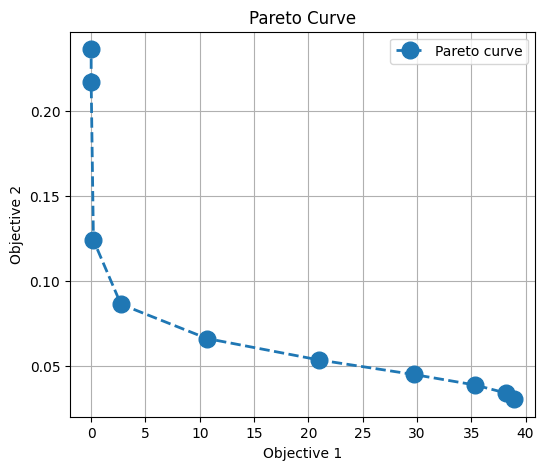

In [144]:
plt.figure(figsize=(6, 5))
plt.plot(Q1_value, Q2_value , lw=2, label="Pareto curve", marker='o', linestyle='dashed', markersize=12)
plt.xlabel("Objective 1")
plt.ylabel("Objective 2")
plt.title("Pareto Curve")
plt.legend()
plt.grid(True)
plt.show()

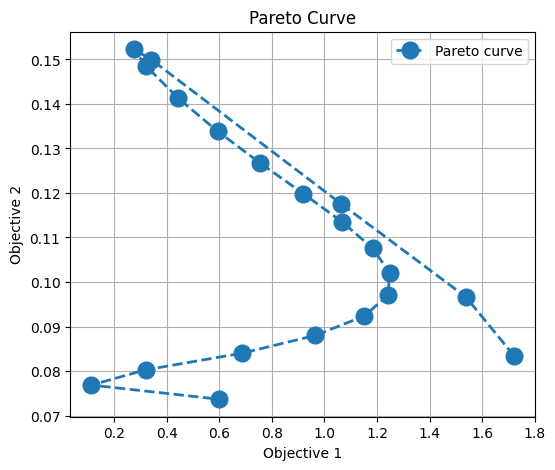

In [104]:
plt.figure(figsize=(6, 5))
plt.plot(Q1_value, Q2_value , lw=2, label="Pareto curve", marker='o', linestyle='dashed', markersize=12)
plt.xlabel("Objective 1")
plt.ylabel("Objective 2")
plt.title("Pareto Curve")
plt.legend()
plt.grid(True)
plt.show()

In [80]:
import cvxpy as cp
def solve_dfmv_sdp(n: int,
                   Vlist: list,
                   hyper_edges_list: list,
                   solver: str = "SCS",
                   verbose: bool = False,
                   eps: float = 1e-8):
    """
    Maximize t
    s.t. for all edges (i,j): (w_ij/2)*(1 - X_ij) >= t   [because ||v_i-v_j||^2 = 2(1 - <v_i,v_j>)]
         diag(X) = 1,  X >> 0

    Returns:
        t_star (float): optimal Rawlsian value of the SDP 
        X_star (np.ndarray): n x n optimal Gram matrix
        V (np.ndarray): n x r factor (rows are the vectors v_i), so X_star = V @ V.T
    """
    # Variables
    X = cp.Variable((n, n), PSD=True)
    t = cp.Variable()

    # Constraints
    cons = [cp.diag(X) == 1]
    for V_instance, hyper_edge in zip(Vlist, hyper_edges_list):
        cons += [cp.sum((len(hyper_edge)**2)*cp.multiply(V_instance, X)) >= t] 

    prob = cp.Problem(cp.Maximize(t), cons)
    prob.solve(solver=solver, verbose=verbose)

    if prob.status == cp.OPTIMAL:
        print("Optimal solution found.")
       # print(f"Optimal value: {prob.value}")
        #print(f"Optimal x: {X.value}")
    elif prob.status == cp.OPTIMAL_INACCURATE:
        print("Optimal solution found, but potentially inaccurate.")
        #print(f"Optimal value: {prob.value}")
        #print(f"Optimal x: {X.value}")
    else:
        print(f"Problem not solved to optimality. Status: {prob.status}")
        
    if X.value is None:
        raise RuntimeError("SDP did not return a solution. Try a different solver (e.g. MOSEK, SCS) or tune settings.")

    X_star = 0.5*(X.value + X.value.T)
    
    lam, Q = np.linalg.eigh(X_star)
    pos = lam > eps
    if not np.any(pos):
        V = np.zeros((n, 1))
    else:
        V = Q[:, pos] @ np.diag(np.sqrt(lam[pos]))  
    return float(t.value), X_star, V

In [81]:
hyper_edges_list = []
for hyper_edge_matrix in Vlist:
    hyper_edge = []
    hyper_edges_list.append(set(np.where(hyper_edge_matrix != 0.0)[1]))

In [82]:
t, X, V = solve_dfmv_sdp(n= Vlist[0].shape[0],
                         hyper_edges_list = hyper_edges_list,
                         Vlist=Vlist)

Optimal solution found.


In [83]:
t

2.3999986124066712

In [84]:
1/np.pi * (np.arccos(1-2*t))

/tmp/job_32496002/step_0.0/ipykernel_314815/1445315678.py:1: RuntimeWarning: invalid value encountered in arccos
  1/np.pi * (np.arccos(1-2*t))


nan

In [ ]:
num_samples = 50
values = []
for sample_idx in range(num_samples):
    array = np.random.choice([-1, 1], size=V.shape[0], p=[0.5, 0.5])
    values.append(array@V@array.transpose())

In [13]:
print(np.max(values))

89.91666666666669


# Test max vs fair

In [2]:
import pickle
import networkx as nx
import pennylane as qml
from joblib import Parallel, delayed
from pennylane import numpy as np
from itertools import combinations

In [11]:
def make_M_V(P, w):
    M = P @ np.diag(w) @ P.T
    return M, np.diag(P @ w) - M

In [40]:
hypergraph_name = f"6_3_1_0"
print("Name: ", hypergraph_name)
P = np.load(f'/work/acslab/users/baobach/quantum_hypergraph/QuantumHypergraphPartitioning/data/karloff/numpy_20/{hypergraph_name}.npy')
M, V = make_M_V(P, np.ones(P.shape[1]))
Vlist = []
Q = V
Vlist = [np.diag(P[:, i]) - P[:, i].reshape(P.shape[0], 1) * P[:, i].reshape(1, P.shape[0]) for i in range(P.shape[1])]

Name:  6_3_1_0


In [49]:
n_wires = Q.shape[0]
triu_indices = np.triu_indices(Q.shape[0])
edge_list = []
for (u, v) in zip(triu_indices[0], triu_indices[1]):
    if u == v:
        continue
    elif Q[u][v] != 0.0:
        edge_list.append((u, v))
num_edges = len(edge_list)
print("Number of edges: ", num_edges)

Number of edges:  90


In [51]:
len(edge_list)

90

In [35]:
hyper_edges_list = []
for hyper_edge_matrix in Vlist:
    hyper_edge = []
    hyper_edges_list.append(set(np.where(hyper_edge_matrix != 0.0)[1]))
n_wires = Vlist[0].shape[0]
print("Hyper edges:", hyper_edges_list[0])
edge_list = []
hyper_edges_clique_enum = []
hyper_edge_idx = 0
for hyper_edge in hyper_edges_list:
    for edge in combinations(hyper_edge, 2):
        edge_list.append((np.min(edge), np.max(edge), float(Vlist[hyper_edge_idx][np.min(edge)][np.max(edge)])))
    hyper_edges_clique_enum.append(list(combinations(hyper_edge, 2)))
    hyper_edge_idx += 1
print("edge list: ", len(edge_list))
print("Len set edge list: ", len(set(edge_list)))
num_edges = len(edge_list)

Hyper edges: {0, 1, 5, 9}
edge list:  180
Len set edge list:  90


In [36]:
edge_list

[(0, 1, -0.0625),
 (0, 5, -0.0625),
 (0, 9, -0.0625),
 (1, 5, -0.0625),
 (1, 9, -0.0625),
 (5, 9, -0.0625),
 (0, 1, -0.0625),
 (0, 6, -0.0625),
 (0, 8, -0.0625),
 (1, 6, -0.0625),
 (1, 8, -0.0625),
 (6, 8, -0.0625),
 (0, 9, -0.0625),
 (0, 2, -0.0625),
 (0, 4, -0.0625),
 (2, 9, -0.0625),
 (4, 9, -0.0625),
 (2, 4, -0.0625),
 (0, 2, -0.0625),
 (0, 6, -0.0625),
 (0, 7, -0.0625),
 (2, 6, -0.0625),
 (2, 7, -0.0625),
 (6, 7, -0.0625),
 (0, 8, -0.0625),
 (0, 3, -0.0625),
 (0, 4, -0.0625),
 (3, 8, -0.0625),
 (4, 8, -0.0625),
 (3, 4, -0.0625),
 (0, 3, -0.0625),
 (0, 5, -0.0625),
 (0, 7, -0.0625),
 (3, 5, -0.0625),
 (3, 7, -0.0625),
 (5, 7, -0.0625),
 (1, 13, -0.0625),
 (1, 12, -0.0625),
 (1, 5, -0.0625),
 (12, 13, -0.0625),
 (5, 13, -0.0625),
 (5, 12, -0.0625),
 (1, 18, -0.0625),
 (1, 12, -0.0625),
 (1, 6, -0.0625),
 (12, 18, -0.0625),
 (6, 18, -0.0625),
 (6, 12, -0.0625),
 (1, 8, -0.0625),
 (8, 19, -0.0625),
 (8, 13, -0.0625),
 (1, 19, -0.0625),
 (1, 13, -0.0625),
 (13, 19, -0.0625),
 (1, 18, -

In [7]:
import pickle
with open("quantum_results/max_cut_6_3_1_0_noiseless_np15_ma_p=3_maxiter=300_seed=42.pkl", "rb") as f:
    result = pickle.load(f)

In [8]:
result

[29.9961,
 -26.24792256814348,
 (tensor([[-2.86601026e+00, -2.85622880e+00, -3.89266583e+00],
          [-2.56336433e+00, -2.54567369e+00, -1.55577164e-01],
          [-3.19518325e+00, -3.17265360e+00, -2.35976979e-01],
          [-3.17593315e-01, -2.01677109e-01, -5.41806213e-01],
          [ 1.14876894e-02, -3.48502397e+00,  1.14963059e+00],
          [ 2.07309285e-01, -2.32116054e-01, -1.86860057e-02],
          [-2.16097380e+00, -2.15650258e+00, -3.41148983e+00],
          [-1.96085181e+00, -2.49417929e+00, -6.00486215e-01],
          [-2.01722877e+00, -2.00973703e+00, -3.24438427e+00],
          [ 1.54044197e-01,  1.23254996e+01,  1.78255984e+00],
          [-2.00606274e+00, -1.99802384e+00, -2.39171731e+00],
          [-1.65826238e-02,  8.03197517e-02, -7.08131655e+00],
          [-1.15255224e+00,  1.14045602e+00, -2.85261513e+00],
          [-8.13397386e-01,  8.05453733e-01, -3.05314481e+00],
          [-3.47006118e+00, -3.45705579e+00, -3.98948698e+00],
          [-3.09116060e+

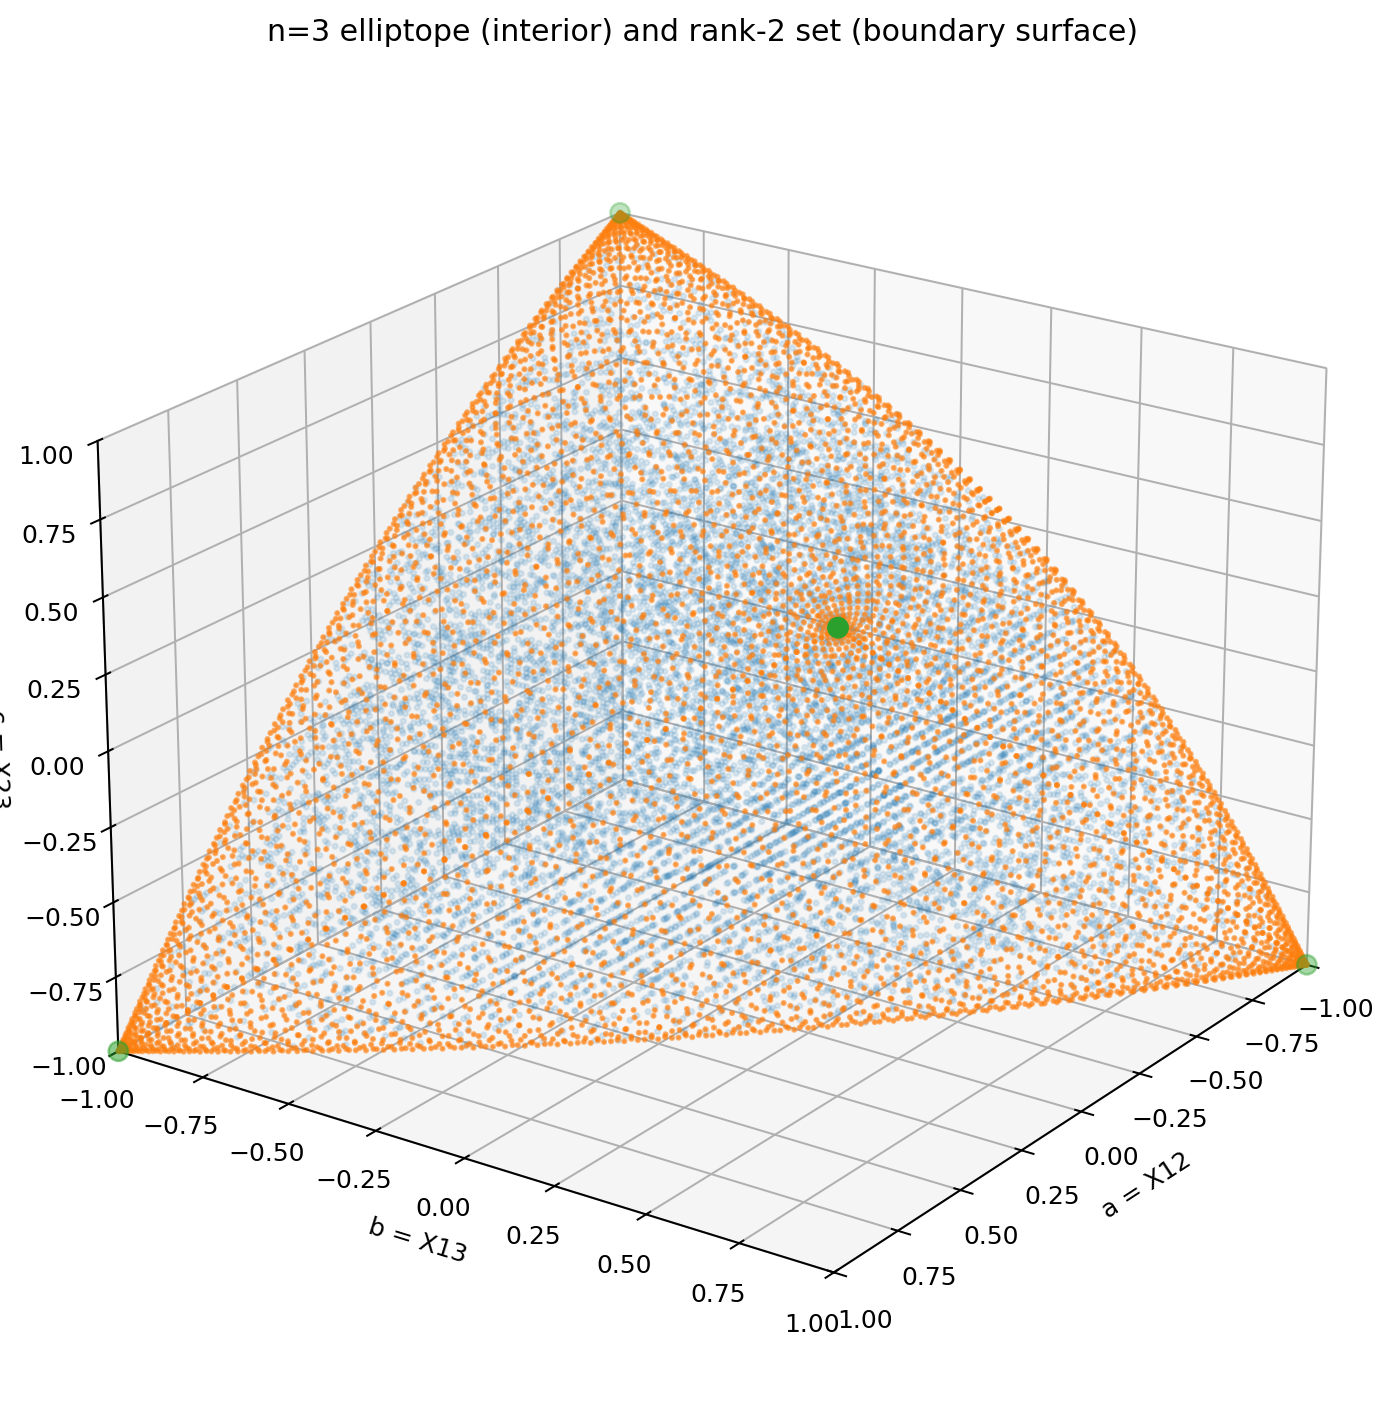

Saved figure to: /mnt/data/elliptope_rank2_n3.png


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# ------------------------------------------------------------
# Visualize the n=3 elliptope and its rank-2 boundary
#
# Correlation matrix:
#   X = [[1, a, b],
#        [a, 1, c],
#        [b, c, 1]]
#
# Elliptope condition:
#   X >= 0  <=>  1 + 2abc - a^2 - b^2 - c^2 >= 0
#
# Rank-2 boundary:
#   det(X) = 0
# ------------------------------------------------------------

def det_expr(a, b, c):
    return 1 + 2 * a * b * c - a * a - b * b - c * c

# --- Sample the elliptope interior on a grid ---
grid_n = 45
vals = np.linspace(-1.0, 1.0, grid_n)
A, B, C = np.meshgrid(vals, vals, vals, indexing="ij")
D = det_expr(A, B, C)
mask = D >= -1e-10

a_in = A[mask]
b_in = B[mask]
c_in = C[mask]

# Downsample interior points for a readable 3D scatter
max_points = 12000
if a_in.size > max_points:
    rng = np.random.default_rng(0)
    idx = rng.choice(a_in.size, size=max_points, replace=False)
    a_in = a_in[idx]
    b_in = b_in[idx]
    c_in = c_in[idx]

# --- Parameterize the rank-2 surface using circle angles ---
# Fix theta1 = 0, then
#   a = cos(theta2), b = cos(theta3), c = cos(theta2 - theta3)
m = 110
theta2 = np.linspace(0, 2 * np.pi, m)
theta3 = np.linspace(0, 2 * np.pi, m)
T2, T3 = np.meshgrid(theta2, theta3, indexing="ij")

a_s = np.cos(T2).ravel()
b_s = np.cos(T3).ravel()
c_s = np.cos(T2 - T3).ravel()

# --- Plot ---
fig = plt.figure(figsize=(10, 8), dpi=180)
ax = fig.add_subplot(111, projection="3d")

# Interior of the elliptope
ax.scatter(a_in, b_in, c_in, s=4, alpha=0.12)

# Rank-2 surface
ax.scatter(a_s, b_s, c_s, s=2, alpha=0.35)

# Mark the four cut / rank-1 points
cut_points = np.array([
    [ 1,  1,  1],
    [ 1, -1, -1],
    [-1,  1, -1],
    [-1, -1,  1],
], dtype=float)
ax.scatter(cut_points[:, 0], cut_points[:, 1], cut_points[:, 2], s=60)

ax.set_xlabel("a = X12")
ax.set_ylabel("b = X13")
ax.set_zlabel("c = X23")
ax.set_title("n=3 elliptope (interior) and rank-2 set (boundary surface)")
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_zlim(-1, 1)
ax.view_init(elev=22, azim=35)

#out_path = "/mnt/data/elliptope_rank2_n3.png"
plt.tight_layout()
#plt.savefig(out_path, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {out_path}")